<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E6%BB%BE%E5%8B%95%E5%BC%8F%E9%A0%90%E6%B8%ACy2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import xgboost as xgb
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import pickle

# --- Data Loading and Preprocessing (as in your original code) ---
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'
for i in df.columns:
    df[i] = pd.to_numeric(df[i], errors='coerce')

# select by rule
coal_low = df[df["MLUT4_FIQ-2BTCF"] < 20]
sox = df["MLUT4_AT-240"]
constant_sox_indices = sox[sox.shift(1) == sox][(sox.shift(2) == sox) & (sox.shift(-1) == sox)].index
constant_sox = df.loc[constant_sox_indices]
common_index = coal_low.index.union(constant_sox.index)
select_df = df.loc[~df.index.isin(common_index), :]

# select features
with open("features2.pkl", "rb") as f:
    features = pickle.load(f)

# define y_col
y_col = 'DeSOx_2nd'
select_df = select_df[features+[y_col]]

# --- Modeling Code (Corrected Part) ---
def train_model(train_X, train_y):
    model = xgb.XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        learning_rate=0.01,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        tree_method='hist'
    )
    return model.fit(train_X, train_y)

# 1. 時間排序
select_df = select_df.sort_index().reset_index(drop=True)

# 2. 設定
target_col = y_col
time_windows_len = 100 #<--- 調整這裡

# 加入前一期目標欄位當特徵
select_df["prev_target"] = select_df[target_col].shift(1)

# 效率不應該低於0
select_df = select_df[select_df["prev_target"]>0]
select_df = select_df[select_df[y_col]>0]

# 刪除因 shift 產生的 NaN 資料
select_df = select_df.dropna().reset_index(drop=True)

# 定義特徵欄位除了時間跟target_col不能用其他都可以用
feature_cols = [col for col in select_df.columns if col not in ['timestamp', target_col]]

# 開始訓練的索引
start_idx = time_windows_len

# 計算total_steps
total_steps = len(select_df) - start_idx

# 3. 儲存預測結果
predictions = []
abs_errors = []
thresholds = []
indices = []

# To store recent errors for threshold calculation for the *current* model
current_model_recent_errors = []
threshold_update_window = 100 # Calculate threshold from last 100 errors
percentile_for_threshold = 90 # 90th percentile of recent errors

# 4. 初始化進度條
pbar = tqdm(total=total_steps)

# 5. 動態預測迴圈
i = start_idx
error_exceeded_threshold = True  # Start with training a model

while i < len(select_df):
    # 早停判斷<不得移除>
    print(pbar)
    if pbar.n >= 1000: # This means it will stop after 1500 predictions, not 1000 training steps.
        break

    # 判斷是否要建模 並記錄
    if 'current_model' not in locals() or error_exceeded_threshold:
        train_df = select_df.iloc[i - time_windows_len:i]
        train_X = train_df[feature_cols]
        train_y = train_df[target_col]

        # train model start
        current_model = train_model(train_X, train_y)

        # Reset recent errors for the new model
        current_model_recent_errors = []
        # For the first prediction after re-training, we won't have enough recent errors
        # to calculate a meaningful threshold. We can set a default or wait.
        # Here, we'll simply let the first few errors build up before calculating.
        current_threshold = np.inf # Set a very high threshold initially for a newly trained model

        error_exceeded_threshold = False # Reset flag

    # 預測i
    test_row = select_df.iloc[i]
    test_X = test_row[feature_cols].values.reshape(1, -1)
    true_y = test_row[target_col]
    pred_y = current_model.predict(test_X)[0]
    error = abs(pred_y - true_y)

    # Add the current error to the list of recent errors for this model
    current_model_recent_errors.append(error)

    # If we have enough recent errors, calculate the threshold for the *current* model's performance
    if len(current_model_recent_errors) >= threshold_update_window:
        current_threshold = np.percentile(current_model_recent_errors[-threshold_update_window:], percentile_for_threshold)
    elif len(current_model_recent_errors) > 0: # If less than window size, use all available errors
        current_threshold = np.percentile(current_model_recent_errors, percentile_for_threshold)
    else:
        current_threshold = np.inf # Should ideally not happen after first few predictions

    # 紀錄
    predictions.append(pred_y)
    abs_errors.append(error)
    thresholds.append(current_threshold)
    indices.append(i)

    # 更新進度條
    pbar.update(1)

    # 根據預測i的結果判斷是否要設置error_exceeded_threshold
    # The check for re-training now uses the threshold calculated from actual recent test errors
    if error > current_threshold:
        error_exceeded_threshold = True
        # If error exceeds, a new model will be trained in the next iteration
        # and 'i' increments by 1
        i += 1
    else:
        # If error does not exceed, stay with the current model for the next prediction
        # 'i' increments by 1, and the loop will try to predict 'i+1' with the *same* model
        i += 1
        error_exceeded_threshold = False # Continue using current model

# 結束訓練
pbar.close()

# 6. 輸出結果表
result_df = select_df.loc[indices].copy()
result_df['prediction'] = predictions
result_df['abs_error'] = abs_errors
result_df['threshold'] = thresholds

# 預覽結果
print(result_df.head())

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 指標評估
y_true = result_df[y_col]
y_pred = result_df['prediction']

# Calculate R-squared
r2 = r2_score(y_true, y_pred)
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Calculate MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100 if np.any(y_true != 0) else 0


# 假設 r2, rmse, mape 是事先計算好的指標
metrics = {
    'Metric': ['R-squared', 'RMSE', 'MAPE'],
    'Value': [r2, rmse, mape],
    'Unit': ['', '', '%']
}

df_metrics = pd.DataFrame(metrics)
df_metrics

  0%|          | 1/52082 [00:00<1:44:27,  8.31it/s]

  0%|          | 3/52082 [00:00<1:44:27,  8.31it/s]


  0%|          | 6/52082 [00:00<51:17, 16.92it/s]

  0%|          | 7/52082 [00:00<51:17, 16.92it/s]


  0%|          | 14/52082 [00:00<31:05, 27.91it/s]

...

  2%|▏         | 979/52082 [00:27<14:39, 58.13it/s]

  2%|▏         | 981/52082 [00:27<14:39, 58.13it/s]


  2%|▏         | 1000/52082 [00:28<23:51, 35.68it/s]

  2%|▏         | 1000/52082 [00:28<14:33, 58.45it/s]
     MLUT4_FT-957  MLUT4_FT-956  MLUT4_FIC-231C  MLUT4_FIC-231B  \
100   3919.870732   3986.234732       16.858142             0.0   
101   3922.900231   3984.023475       16.856887             0.0   
102   3924.403887   3986.219920       16.855632             0.0   
103   3925.721410   3984.826874       16.854377             0.0   
104   3919.279922   3983.727748       16.853122             0.0   

     MLUT4_PDT-232  MLUT4_PIC-233  MLUT4_TE-252D  MLUT4_FIC-231A  \
100      76.371270     971.592529     857.535397       21.013352   
101      76.991011     971.485716     859.417612       20.994628   
102      76.939404     969.908187     860.947126       20.975905   
103      77.086023     970.941871     859.555342       20.957181   
104      77.501165     974.520517     856.837148       21.056347   

     MLUT4_AIA792101B  MLUT4_IT-E7925B  ...  MLUT4_FT-232  MLUT4_FQ-205  \
100          6.900000        17.654531  ...    330.647701   

,Metric,Value,Unit
0,R-squared,0.694333,
1,RMSE,0.035520,
2,MAPE,2.976494,%


# 預測線圖

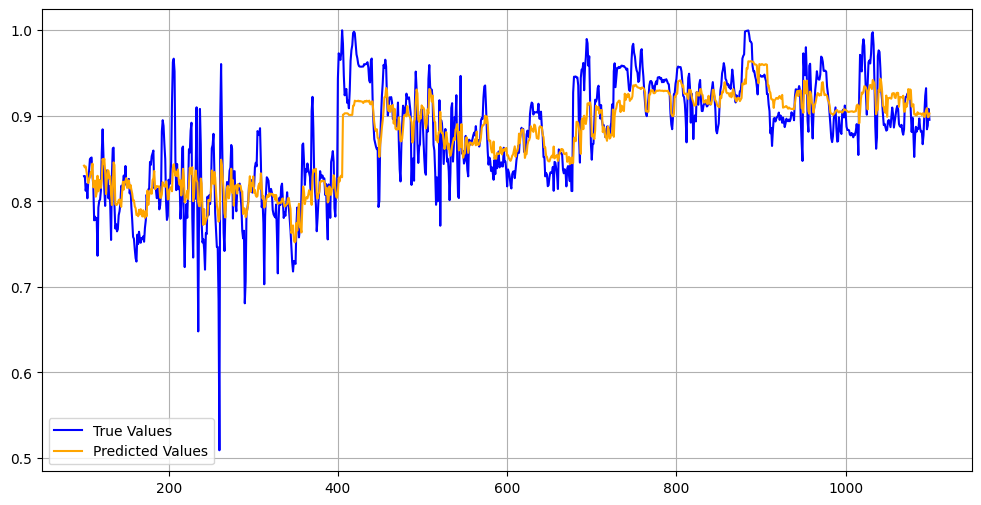

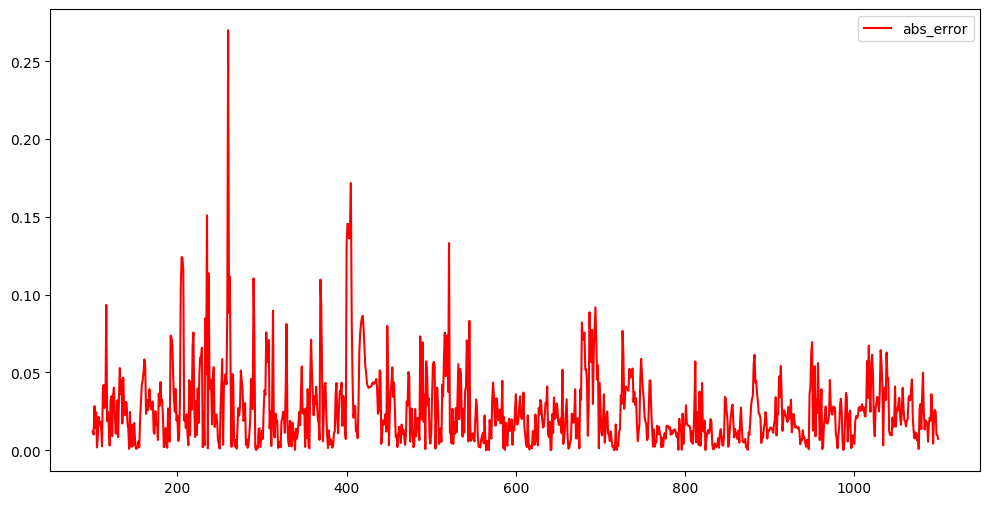

In [29]:
import matplotlib.pyplot as plt

# 畫圖
plt.figure(figsize=(12, 6))
plt.plot(result_df[y_col], label='True Values', color='blue')
plt.plot(result_df['prediction'], label='Predicted Values', color='orange')

plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(result_df['abs_error'], label='abs_error', color='red')#換個軸
plt.legend()
plt.show()


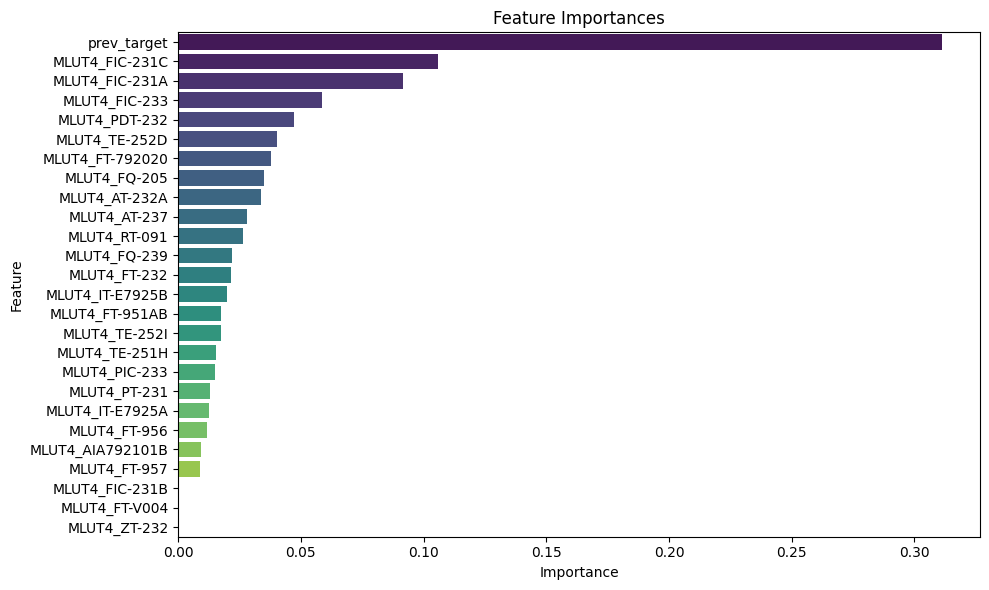

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 建立特徵重要度的 DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': current_model.feature_importances_
})

# 根據重要度排序
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 繪圖
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()
